In [1]:
from paths import PROJECT_ROOT
import sys
sys.path.insert(0, PROJECT_ROOT)

import os
import matplotlib.pyplot as plt
from notebooks.visualization.activations_funcs import get_activation_dictionnary
from notebooks.visualization.random_networks_plots.plot_config import apply_plot_style
from notebooks.visualization.activations_funcs import get_all_connections
plots_dir = os.path.join(PROJECT_ROOT, "plots")
from notebooks.visualization.random_networks_plots.plot_config import RANDOMIZATION_NAMES
NUM_PASSES = 3

apply_plot_style()

# Create plots directory if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)


from utils.helpers import load_neuron_coordinates

from joblib import Memory


cache_dir = os.path.join(PROJECT_ROOT, "notebooks", "visualization", "data", ".joblib_cache")
memory = Memory(location=cache_dir, verbose=0)


@memory.cache
def connections_cached():
    """Disk-cached version of get_all_connections()."""
    return get_all_connections()


@memory.cache
def activations_cached(num_passes: int = 4):
    """Disk-cached wrapper around get_activation_dictionnary()."""
    conn_dict = connections_cached()
    return get_activation_dictionnary(conn_dict, num_passes)

neuron_position_data = load_neuron_coordinates()

# Heavy cached computations
connections_dict = connections_cached()
activations_dict = activations_cached(NUM_PASSES)

# remove random pruned from both
_ = connections_dict.pop(RANDOMIZATION_NAMES["random_pruned"])
_ = activations_dict.pop(RANDOMIZATION_NAMES["random_pruned"])

/home/eudald/Escriptori/doctorat/connectome/connectome/visualization/models_accuracy.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


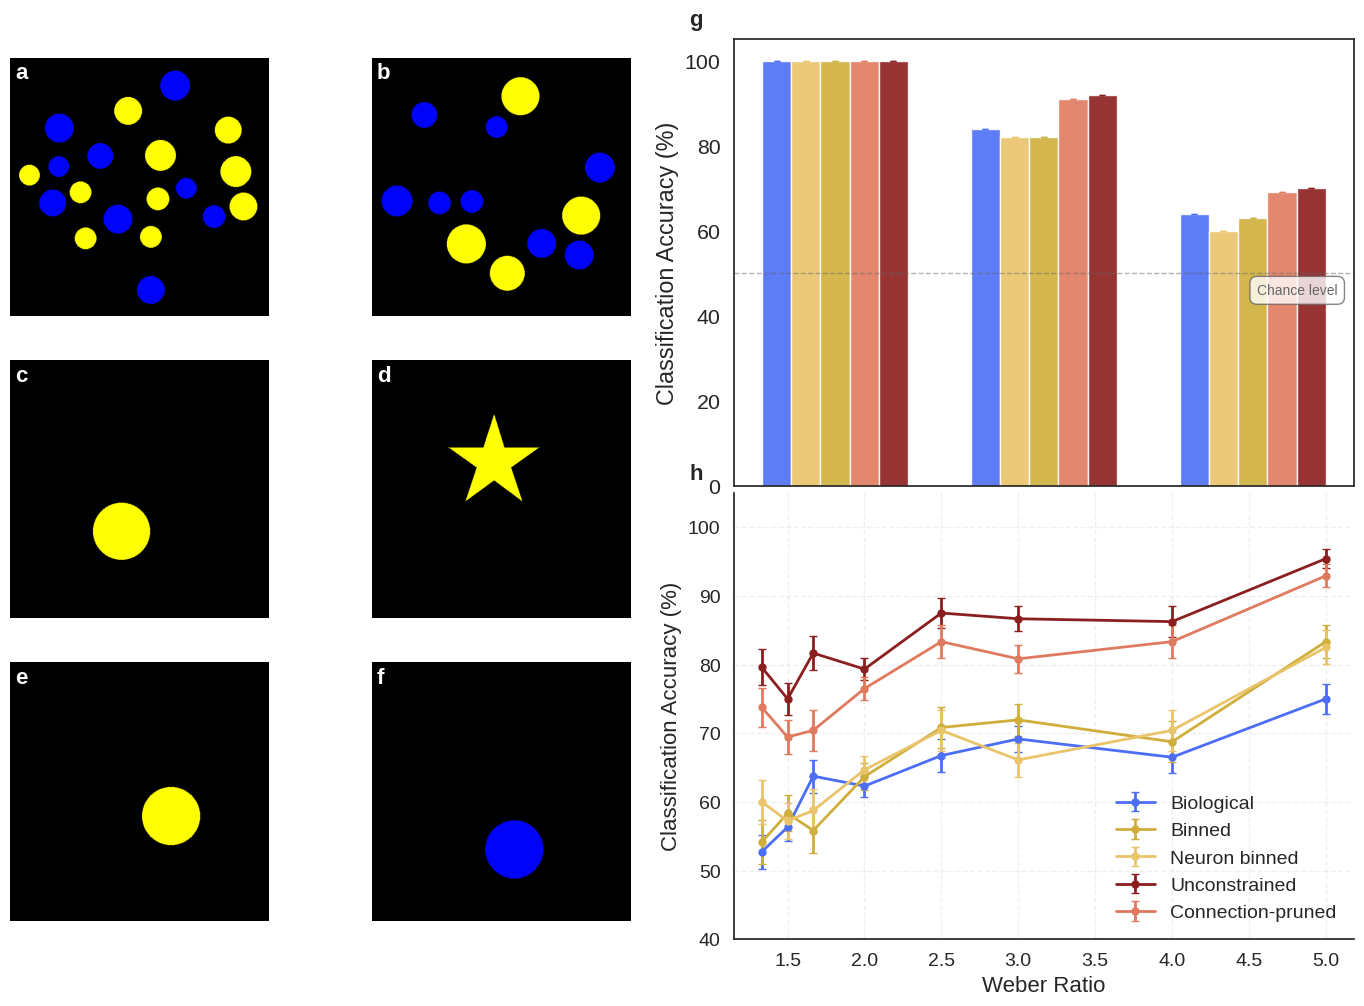

In [3]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.image import imread
import seaborn as sns

plt.close('all')
sns.set_theme(font_scale=1.4, style="white")

ORDER = ["Biological", "Binned", "Neuron binned", "Unconstrained", "Connection-pruned"]
NAME_ALIAS = {
    "biological": "biological",
    "binned": "random_binned",
    "random_binned": "random_binned",
    "neuron_binned": "neuron_binned",
    "unconstrained": "unconstrained",
    "connection_pruned": "connection_pruned",
}

from notebooks.visualization.random_networks_plots import plot_config
from connectome.visualization import plots, task_accuracy_comparison

# Load task images
task_images_dir = os.path.join(PROJECT_ROOT, "notebooks", "visualization", "task_images")
images = [imread(os.path.join(task_images_dir, f"t{i}.png")) for i in range(1, 7)]

# Create figure with gridspec: 6 rows x 4 columns
# Left: images (6 images in 3x2 arrangement, each spanning 2 rows)
# Right: task_accuracy (top) + weber (bottom)
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(6, 4, figure=fig, hspace=0.05, wspace=0.4, left=0.02, right=0.98, top=0.98, bottom=0.08)

# Left section: task images (3x2 arrangement, each image spans 2 rows)
ax_imgs = []
for i in range(6):
    row = (i // 2) * 2  # 0, 0, 2, 2, 4, 4
    col = i % 2         # 0, 1, 0, 1, 0, 1
    ax = fig.add_subplot(gs[row:row+2, col])
    ax.imshow(images[i])
    ax.axis('off')
    ax.set_aspect('equal')
    ax_imgs.append(ax)

# Right section: task_accuracy (top half)
ax_task = fig.add_subplot(gs[0:3, 2:4])
task_accuracy_comparison(ax=ax_task, show_legend=False)

# Right section: weber (bottom half)
ax_weber = fig.add_subplot(gs[3:6, 2:4])
plots.plot_weber_by_randomization(
    folder=os.path.join(PROJECT_ROOT, "supplementary_data"),
    min_weber=1.2,
    ax=ax_weber,
    show_legend=True
)

# Panel labels (a-f for images inside plots in white, g and h outside)
for i, ax in enumerate(ax_imgs):
    ax.text(0.02, 0.98, chr(ord('a') + i), transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='left', color='white')

ax_task.text(-0.05, 1.02, 'g', transform=ax_task.transAxes, 
             fontsize=16, fontweight='bold', va='bottom', ha='right')
ax_weber.text(-0.05, 1.02, 'h', transform=ax_weber.transAxes, 
              fontsize=16, fontweight='bold', va='bottom', ha='right')

plt.show()

fig.savefig(os.path.join(plots_dir, "figure_3.pdf"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(plots_dir, "figure_3.png"), dpi=300, bbox_inches='tight')